# regrid
对网格进行插值变换

In [1]:
import iris
import iris.plot as iplt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from nmc_met_graphics.cmap import ctables
from nmc_met_graphics.plot.mapview import add_china_map_2cartopy

from nimm import config
import nimm.cli as nimmcli
from nimm.io.load import load_cube
from nimm.utils.filesystem import (
    FileSystem, 
    filename_getmeta, 
    filename_update,
)

test_dir = config['test_dir']

In [1]:
! ../../bin/nimm tran_regrid --help

Usage: nimm regrid [OPTIONS] cube target-grid [land-sea-mask]

Regrids source cube data onto a target grid. Optional land-sea awareness.

Arguments:
  cube                 Source cube to be regridded. (type: INPUTCUBE)
  target-grid          Cube defining the spatial grid onto which to regrid the
                       source data.  If also using land_sea_mask-aware
                       regridding then this must be land_binary_mask data.
                       (type: INPUTCUBE)
  land-sea-mask        Cube describing the land_binary_mask on the source grid
                       if land-sea aware regridding is required, with land
                       points set to one and sea points set to zero. This can be
                       a larger domain than cube, so long as cube is a strict
                       cut-out (not a reprojection) of the land_sea_mask domain.
                       (type: INPUTCUBE)

Options:
  --regrid-mode=STR    Selects which regridding techniques to use. Def

In [2]:
model_file_sys = FileSystem(
    file_dir=test_dir, 
    data_name="ecmf_c1d_global", 
    var_name="air_temperature",
)
truth_file_sys = FileSystem(
    file_dir=test_dir,
    data_name="hrcldas_1km_1h_rt",
    var_name="air_temperature",
)

In [3]:
fcst_file = model_file_sys.get(frt='20221002T1200Z', fp=24)
fcst_regrid_file = model_file_sys.get(frt='20221002T1200Z', fp=24, transform='regridded')
truth_file = truth_file_sys.get(time=filename_getmeta(fcst_file, name='time'))

command = f"../../bin/nimm tran_regrid {fcst_file} {truth_file} --output={fcst_regrid_file} \
    --compression-level=4 --least-significant-digit=2 --overwrite-output"
! $command

In [4]:
cube = load_cube(fcst_regrid_file)
cube

<iris 'Cube' of air_temperature / (K) (realization: 1; latitude: 4501; longitude: 7001)>

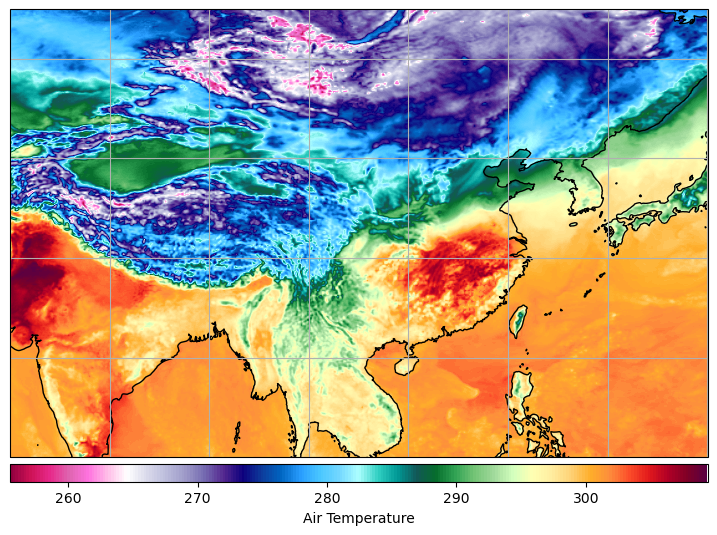

In [5]:
# 显示模式数据
plt.figure(figsize=[9,9])
cnf  = iplt.pcolormesh(cube[0], cmap=ctables.cm_temp())
bar  = plt.colorbar(cnf, label='Air Temperature', 
                    orientation="horizontal", pad=0.01, aspect=40)
plt.gca().coastlines()
plt.gca().gridlines()
iplt.show()

In [3]:
# 对同一起报时间的多个预报时效进行处理.
fcst_files = model_file_sys.generate_files(frt='20221002T1200Z', fp=list(range(0,78,6)))

for fcst_file in fcst_files:
    fcst_regrid_file = filename_update(fcst_file, transform='regridded')
    truth_file = truth_file_sys.get(time=filename_getmeta(fcst_file, meta='time'))

    command = f"../../bin/nimm tran_regrid {fcst_file} {truth_file} --output={fcst_regrid_file} \
        --compression-level=4 --least-significant-digit=2 --overwrite-output"
    ! $command